# EnsemblePrompt 資料流逐步檢視（PPI 模式）

用**真實模組 + 真實 HPRD50 資料**走過整條 pipeline，每一步印出實際的**型別、欄位、內容**，
看清每個中間變數的格式與轉換。

```
loadMethodPool      ─▶ promptTechPoolDict   dict[method] = {itemKey: text}
genPromptCmb        ─▶ promptCmbDf          DataFrame[promptCmbID, promptText]
loadDataset         ─▶ datasetDf            DataFrame  +  labelSet (LabelSet)
buildPromptInfoPPI  ─▶ promptInfoDf         DataFrame  (內部先產 userPromptDf)
[推論]              ─▶ raw.csv              responseAns... (離線合成, schema 同 production)
parseToResultDf     ─▶ resultDf             long DataFrame (每 item 一列、含 runKey)
pivotPartial/Full   ─▶ partialDf / fullDf   wide DataFrame (runKey 變欄；full = partial + __raw)
Evaluate            ─▶ evalSummary.csv + 圖
```

> **Step 4** 真實流程會打 Ollama；這裡離線合成 `responseAns`（schema 嚴格對齊 `RAW_CSV_COLS`），
> 讓 notebook 不依賴本機模型也能跑完，且下游資料格式完全一致。

In [1]:
# 唯一缺的相依套件是 tenacity（其餘 requirements 已安裝），缺了就裝
try:
    import tenacity  # noqa: F401
except ImportError:
    import sys, subprocess
    subprocess.run([sys.executable, "-m", "pip", "install", "tenacity==9.1.4"], check=True)
print("deps ready")

deps ready


In [2]:
import os, sys, json, shutil
from pathlib import Path
import pandas as pd
from IPython.display import display, Markdown, Image

pd.set_option("display.max_colwidth", 90)
pd.set_option("display.width", 180)

# 找 repo 根（含 PromptExecution/），切過去並加進 sys.path，
# 讓 "data/..." 相對路徑與 `import PromptExecution` 不論從哪啟動都可用
ROOT = Path.cwd()
while not (ROOT / "PromptExecution").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
os.chdir(ROOT)
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
print("repo root:", ROOT)

def md(text):
    display(Markdown(text))

def show_df(df, title, n=5):
    md(f"**{title}** · type=`{type(df).__name__}` · shape=`{df.shape}`")
    md("欄位：" + ", ".join(f"`{c}`" for c in df.columns))
    display(df.head(n))

def show_cell(value, label):
    md(f"**{label}** · python type=`{type(value).__name__}`")
    print(value)

# 所有產物寫到獨立資料夾，不覆蓋既有輸出
INSPECT = Path("data/_notebook_inspect/PPI")
if INSPECT.exists():
    shutil.rmtree(INSPECT)
INSPECT.mkdir(parents=True, exist_ok=True)
print("output dir:", INSPECT)

repo root: C:\Users\s0810\Desktop\EnsemblePrompt-ML
output dir: data\_notebook_inspect\PPI


## Step 1 — 生成 Prompt 組合
`方法池 YAML → promptTechPoolDict(dict) → genPromptCmb → promptCmbDf(DataFrame)`

In [3]:
from PromptExecution.PromptCmbGen import PromptCmbGen

promptTechPath = "data/PromptGeneration/PromptTechnique_PPI.yaml"
pg = PromptCmbGen()

# 1a. 方法池 YAML → dict[method] = {itemKey: text}
promptTechPoolDict = pg.loadMethodPool(promptTechPath)
md(f"**promptTechPoolDict** · type=`{type(promptTechPoolDict).__name__}` · methods=`{list(promptTechPoolDict)}`")
oneMethod = next(iter(promptTechPoolDict))
md(f"方法 `{oneMethod}` 的項目（itemKey → text 前 60 字）：")
for k, v in promptTechPoolDict[oneMethod].items():
    print(f"  {oneMethod}{str(k).zfill(2)} : {str(v)[:60]!r}")

**promptTechPoolDict** · type=`dict` · methods=`['EMO', 'Role', 'S2A', 'RAR', 'RE2', 'Self_ASK', 'AP', 'Contrastive', 'Few_shot']`

方法 `EMO` 的項目（itemKey → text 前 60 字）：

  EMO01 : 'This is very important to my career\n'
  EMO02 : 'If you misclassify an interaction here, it could corrupt the'
  EMO03 : 'If you make a mistake, I will lose my job.\n'
  EMO04 : 'The accuracy of your classification will directly impact the'
  EMO05 : 'Your performance on this task will be a critical factor in m'


In [4]:
# 1b. 枚舉組合 → promptCmbDf（重構後一路傳到底的 DataFrame）
promptCmbDf = pg.genPromptCmb(
    promptTechPoolDict,
    b_exhaustiveCmb=True,
    selectedPromptType=["EMO", "Few_shot"],
    maxCmbNum=1,            # 只取 size-1 組合，數量小好讀
    manualPromptCmb=[],
)
show_df(promptCmbDf, "promptCmbDf（genPromptCmb 回傳）", n=len(promptCmbDf))
md("第 1 筆 `promptText` 全文：")
print(promptCmbDf.iloc[0]["promptText"])

**promptCmbDf（genPromptCmb 回傳）** · type=`DataFrame` · shape=`(8, 2)`

欄位：`promptCmbID`, `promptText`

,promptCmbID,promptText
0,EMO01,This is very important to my career\n
1,EMO02,"If you misclassify an interaction here, it could corrupt the interactome knowledge bas..."
2,EMO03,"If you make a mistake, I will lose my job.\n"
3,EMO04,The accuracy of your classification will directly impact the reliability of the protei...
4,EMO05,Your performance on this task will be a critical factor in my professional reputation ...
5,Few_shot01,"Example 1:\nText: ""PROTEIN1 directly binds to PROTEIN2 and forms a stable complex in v..."
6,Few_shot02,"Example 1:\nText: ""PROTEIN1 directly binds to PROTEIN2 and forms a stable complex in v..."
7,Few_shot03,"Example 1:\nText: ""PROTEIN1 directly binds to PROTEIN2 and forms a stable complex in v..."


第 1 筆 `promptText` 全文：

This is very important to my career



In [5]:
# 1c. 存檔（一律覆蓋）→ 看落地 CSV
promptCmbPath = INSPECT / "ppiPromptCmb.csv"
pg.savePromptCmb(promptCmbDf, promptCmbPath)
md(f"落地檔 `{promptCmbPath}` 讀回（與記憶體 DataFrame 同構）：")
display(pd.read_csv(promptCmbPath, encoding="utf-8-sig").head())

落地檔 `data\_notebook_inspect\PPI\ppiPromptCmb.csv` 讀回（與記憶體 DataFrame 同構）：

,promptCmbID,promptText
0,EMO01,This is very important to my career\n
1,EMO02,"If you misclassify an interaction here, it could corrupt the interactome knowledge bas..."
2,EMO03,"If you make a mistake, I will lose my job.\n"
3,EMO04,The accuracy of your classification will directly impact the reliability of the protei...
4,EMO05,Your performance on this task will be a critical factor in my professional reputation ...


## Step 2 — 載入資料集 + 抽 labelSet + checkpoint
`loadDataset → datasetDf(DataFrame), labelSet(LabelSet)`；`loadCompletedTaskRunIDs → set[TaskRunID]`

In [6]:
from PromptExecution.DataLoader import DataLoader

datasetCsvPath = "data/PPIDataset/HPRD50/HPRD50_train.csv"
taskType, labelColumn, sentColumns = "PPI", "label", ["passage"]

dl = DataLoader()
datasetDfFull, labelSet = dl.loadDataset(datasetCsvPath, taskType, labelColumn, sentColumns)

# demo 取前 10 列；真實流程用全量
datasetDf = datasetDfFull.head(10).reset_index(drop=True)
show_df(datasetDf, "datasetDf（loadDataset 回傳，取前 10 列）", n=10)

**datasetDf（loadDataset 回傳，取前 10 列）** · type=`DataFrame` · shape=`(10, 3)`

欄位：`taskID`, `passage`, `label`

,taskID,passage,label
0,HPRD50.d0.s0_0,Cloning and characterization of two evolutionarily conserved subunits ( PROTEIN1 and P...,no
1,HPRD50.d0.s0_1,Cloning and characterization of two evolutionarily conserved subunits ( PROTEIN and PR...,no
2,HPRD50.d0.s0_2,Cloning and characterization of two evolutionarily conserved subunits ( PROTEIN1 and P...,no
3,HPRD50.d1.s0_3,"Identification of residues in the PROTEIN1 that contact the MCP-1 receptor, PROTEIN2",yes
4,HPRD50.d1.s1_4,The receptor binding site of PROTEIN1 also is significantly different from the binding...,no
5,HPRD50.d1.s1_5,The receptor binding site of PROTEIN1 also is significantly different from the binding...,no
6,HPRD50.d1.s1_6,The receptor binding site of PROTEIN also is significantly different from the binding ...,no
7,HPRD50.d1.s2_7,It was previously shown that the N-terminus of PROTEIN1 is critical for binding PROTEIN2,yes
8,HPRD50.d1.s3_8,"To identify the regions of PROTEIN1 that contact its receptor, PROTEIN2 we substituted...",yes
9,HPRD50.d2.s0_9,We tested this point by cotransfecting CHO cells with the genes encoding F beta alpha ...,no


In [19]:
# labelSet：classes 的索引即 labelCode
md(f"**labelSet** · type=`{type(labelSet).__name__}` · classes=`{labelSet.classes}`")
for c in labelSet.classes:
    print(f"  label {c!r:>6} → labelCode {labelSet.labelToLabelCode(c)}")


**labelSet** · type=`LabelSet` · classes=`['no', 'yes']`

  label   'no' → labelCode 0
  label  'yes' → labelCode 1


In [8]:
# checkpoint：輸出資料夾全新 → 空 set
responsePath = INSPECT / "raw.csv"
finishedTaskRunIDSet = dl.loadCompletedTaskRunIDs(responsePath)
md(f"**finishedTaskRunIDSet** · type=`{type(finishedTaskRunIDSet).__name__}` · len=`{len(finishedTaskRunIDSet)}`（全新→空）")
md("元素型別 `TaskRunID(model, promptCmbID, taskID)`，斷點續傳的比對 key。")

**finishedTaskRunIDSet** · type=`set` · len=`0`（全新→空）

元素型別 `TaskRunID(model, promptCmbID, taskID)`，斷點續傳的比對 key。

## Step 3 — 建構待執行任務
內部先把 Task 攤平成 `userPromptDf`，再 × models × prompts → `promptInfoDf`（一列=一筆推論）。

In [20]:
from PromptExecution.TaskBuilder import TaskBuilder, USER_PROMPT_COLS, PROMPT_INFO_COLS

taskTemplate = (
    "Sentence: {passage}\n\n"
    "Task: Based on the sentence, do PROTEIN1 and PROTEIN2 have a protein-protein interaction (PPI)?\n"
    "Answer with exactly one of the allowed labels: no, yes.\n"
)
selectedModels = ["llama3.2:1b"]
tb = TaskBuilder()

# 3a. 內部中間產物 userPromptDf（平常被 buildPromptInfoPPI 包住，這裡手動叫出來看）
userPromptDf = tb._buildUserPromptBatches(
    datasetDf, "PPI", labelColumn, sentColumns, 1, taskTemplate, None, None)
show_df(userPromptDf, "userPromptDf（內部中間產物）", n=3)
md(f"`USER_PROMPT_COLS` = {USER_PROMPT_COLS}")
show_cell(userPromptDf.iloc[0]["itemList"], "itemList[0]（PPI：label 包成單元素 list）")
show_cell(userPromptDf.iloc[0]["contextDict"], "contextDict[0]（context 欄位字典）")
md("**userPrompt[0] 全文：**")
print(userPromptDf.iloc[0]["userPrompt"])

**userPromptDf（內部中間產物）** · type=`DataFrame` · shape=`(10, 4)`

欄位：`taskID`, `itemList`, `userPrompt`, `contextDict`

,taskID,itemList,userPrompt,contextDict
0,HPRD50.d0.s0_0,[{'label': 'no'}],Sentence: Cloning and characterization of two evolutionarily conserved subunits ( PROT...,{'passage': 'Cloning and characterization of two evolutionarily conserved subunits ( P...
1,HPRD50.d0.s0_1,[{'label': 'no'}],Sentence: Cloning and characterization of two evolutionarily conserved subunits ( PROT...,{'passage': 'Cloning and characterization of two evolutionarily conserved subunits ( P...
2,HPRD50.d0.s0_2,[{'label': 'no'}],Sentence: Cloning and characterization of two evolutionarily conserved subunits ( PROT...,{'passage': 'Cloning and characterization of two evolutionarily conserved subunits ( P...


`USER_PROMPT_COLS` = ['taskID', 'itemList', 'userPrompt', 'contextDict']

**itemList[0]（PPI：label 包成單元素 list）** · python type=`list`

[{'label': 'no'}]


**contextDict[0]（context 欄位字典）** · python type=`dict`

{'passage': 'Cloning and characterization of two evolutionarily conserved subunits ( PROTEIN1 and PROTEIN2 of human PROTEIN and their involvement in functional interactions with TFIIIB and RNA polymerase III'}


**userPrompt[0] 全文：**

Sentence: Cloning and characterization of two evolutionarily conserved subunits ( PROTEIN1 and PROTEIN2 of human PROTEIN and their involvement in functional interactions with TFIIIB and RNA polymerase III

Task: Based on the sentence, do PROTEIN1 and PROTEIN2 have a protein-protein interaction (PPI)?
Answer with exactly one of the allowed labels: no, yes.



In [10]:
# 3b. userPromptDf × models × prompts → promptInfoDf
promptInfoDf = tb.buildPromptInfoPPI(
    datasetDf, labelColumn, sentColumns, taskTemplate,
    promptCmbDf, finishedTaskRunIDSet, selectedModels)
show_df(promptInfoDf, "promptInfoDf（buildPromptInfoPPI 回傳）", n=4)
md(f"`PROMPT_INFO_COLS` = {PROMPT_INFO_COLS}")
md(f"列數 = prompts({len(promptCmbDf)}) × tasks({len(datasetDf)}) × models({len(selectedModels)}) = **{len(promptInfoDf)}**")
row0 = promptInfoDf.iloc[0]
show_cell(row0["items"], "items（記憶體中為 list 物件）")
show_cell(row0["context"], "context（記憶體中為 dict 物件）")

**promptInfoDf（buildPromptInfoPPI 回傳）** · type=`DataFrame` · shape=`(80, 7)`

欄位：`taskID`, `model`, `promptCmbID`, `sysPrompt`, `userPrompt`, `items`, `context`

,taskID,model,promptCmbID,sysPrompt,userPrompt,items,context
0,HPRD50.d0.s0_0,llama3.2:1b,EMO01,This is very important to my career\n,Sentence: Cloning and characterization of two evolutionarily conserved subunits ( PROT...,[{'label': 'no'}],{'passage': 'Cloning and characterization of two evolutionarily conserved subunits ( P...
1,HPRD50.d0.s0_1,llama3.2:1b,EMO01,This is very important to my career\n,Sentence: Cloning and characterization of two evolutionarily conserved subunits ( PROT...,[{'label': 'no'}],{'passage': 'Cloning and characterization of two evolutionarily conserved subunits ( P...
2,HPRD50.d0.s0_2,llama3.2:1b,EMO01,This is very important to my career\n,Sentence: Cloning and characterization of two evolutionarily conserved subunits ( PROT...,[{'label': 'no'}],{'passage': 'Cloning and characterization of two evolutionarily conserved subunits ( P...
3,HPRD50.d1.s0_3,llama3.2:1b,EMO01,This is very important to my career\n,"Sentence: Identification of residues in the PROTEIN1 that contact the MCP-1 receptor, ...",[{'label': 'yes'}],{'passage': 'Identification of residues in the PROTEIN1 that contact the MCP-1 recepto...


`PROMPT_INFO_COLS` = ['taskID', 'model', 'promptCmbID', 'sysPrompt', 'userPrompt', 'items', 'context']

列數 = prompts(8) × tasks(10) × models(1) = **80**

**items（記憶體中為 list 物件）** · python type=`list`

[{'label': 'no'}]


**context（記憶體中為 dict 物件）** · python type=`dict`

{'passage': 'Cloning and characterization of two evolutionarily conserved subunits ( PROTEIN1 and PROTEIN2 of human PROTEIN and their involvement in functional interactions with TFIIIB and RNA polymerase III'}


In [11]:
# 3c. 存檔：注意 items/context 在記憶體是物件，落地 CSV 會變 JSON 字串
datasetPromptInfoPath = INSPECT / "datasetPromptInfo.csv"
tb.savePromptInfo(promptInfoDf, datasetPromptInfoPath)
diskDf = pd.read_csv(datasetPromptInfoPath, encoding="utf-8-sig")
show_cell(diskDf.iloc[0]["items"], "落地後 items（CSV 內為 JSON 字串，型別 str）")

**落地後 items（CSV 內為 JSON 字串，型別 str）** · python type=`str`

[{"label": "no"}]


## Step 4 — LLM 推論

In [13]:
from PromptExecution.OllamaEngine import RAW_CSV_COLS
import random
random.seed(42)

# 4b. 合成 responseAns（PPI → {"label": ...}）：多數回 gold、30% 刻意答錯，讓評估不退化
classesLower = [c.lower() for c in labelSet.classes]
def fake_answer(items_list):
    gold = str(items_list[0].get("label", "")).strip().lower()
    pred = gold if gold in classesLower else labelSet.classes[0]
    if random.random() < 0.3:
        pred = next((c for c in labelSet.classes if c.lower() != pred), pred)
    return json.dumps({"label": pred})

rawRecords = []
for r in promptInfoDf.itertuples(index=False):
    rawRecords.append({
        "model": r.model, "promptCmbID": r.promptCmbID, "taskID": r.taskID,
        "systemPrompt": r.sysPrompt, "userPrompt": r.userPrompt,
        "responseAns": fake_answer(r.items),
        "items": json.dumps(r.items, ensure_ascii=False),
        "context": json.dumps(r.context, ensure_ascii=False),
    })
rawDf = pd.DataFrame(rawRecords, columns=RAW_CSV_COLS)
rawDf.to_csv(responsePath, index=False, encoding="utf-8-sig")
show_df(rawDf, "raw.csv（合成，RAW_CSV_COLS）", n=4)
md(f"`RAW_CSV_COLS` = {RAW_CSV_COLS}")
show_cell(rawDf.iloc[0]["responseAns"], "responseAns[0]（LLM 原始 JSON 文字）")

**raw.csv（合成，RAW_CSV_COLS）** · type=`DataFrame` · shape=`(80, 8)`

欄位：`model`, `promptCmbID`, `taskID`, `systemPrompt`, `userPrompt`, `responseAns`, `items`, `context`

,model,promptCmbID,taskID,systemPrompt,userPrompt,responseAns,items,context
0,llama3.2:1b,EMO01,HPRD50.d0.s0_0,This is very important to my career\n,Sentence: Cloning and characterization of two evolutionarily conserved subunits ( PROT...,"{""label"": ""no""}","[{""label"": ""no""}]","{""passage"": ""Cloning and characterization of two evolutionarily conserved subunits ( P..."
1,llama3.2:1b,EMO01,HPRD50.d0.s0_1,This is very important to my career\n,Sentence: Cloning and characterization of two evolutionarily conserved subunits ( PROT...,"{""label"": ""yes""}","[{""label"": ""no""}]","{""passage"": ""Cloning and characterization of two evolutionarily conserved subunits ( P..."
2,llama3.2:1b,EMO01,HPRD50.d0.s0_2,This is very important to my career\n,Sentence: Cloning and characterization of two evolutionarily conserved subunits ( PROT...,"{""label"": ""yes""}","[{""label"": ""no""}]","{""passage"": ""Cloning and characterization of two evolutionarily conserved subunits ( P..."
3,llama3.2:1b,EMO01,HPRD50.d1.s0_3,This is very important to my career\n,"Sentence: Identification of residues in the PROTEIN1 that contact the MCP-1 receptor, ...","{""label"": ""no""}","[{""label"": ""yes""}]","{""passage"": ""Identification of residues in the PROTEIN1 that contact the MCP-1 recepto..."


`RAW_CSV_COLS` = ['model', 'promptCmbID', 'taskID', 'systemPrompt', 'userPrompt', 'responseAns', 'items', 'context']

**responseAns[0]（LLM 原始 JSON 文字）** · python type=`str`

{"label": "no"}


## Step 5 — 解析輸出
`raw.csv → resultDf`（long format，每個 item 展開成一列，解析出 `predLabel` / `trueLabel`，並生成 `runKey = model|promptCmbID` 供下游 pivot）。

In [14]:
from PromptExecution.ResponseParser import ResponseParser
rp = ResponseParser()

rawLoaded = rp.loadResponse(responsePath)
resultDf = rp.parseToResultDf(rawLoaded, labelSet)
show_df(resultDf, "resultDf（parseToResultDf 回傳，long）", n=5)
md("第 1 列完整內容（轉置看欄位）：")
display(resultDf.iloc[[0]].T)

resultPath = INSPECT / "result.csv"
singleDir = INSPECT / "Result_PromptCmb"; singleDir.mkdir(exist_ok=True)
rp.saveResults(resultDf, resultPath, singleDir)
md("Result_PromptCmb 分檔（每個 promptCmbID 一檔）：")
print([p.name for p in singleDir.glob("*.csv")])

**resultDf（parseToResultDf 回傳，long）** · type=`DataFrame` · shape=`(80, 9)`

欄位：`sentID`, `model`, `promptCmbID`, `runKey`, `originalAns`, `trueLabel`, `predLabel`, `responseAns`, `passage`

,sentID,model,promptCmbID,runKey,originalAns,trueLabel,predLabel,responseAns,passage
0,HPRD50.d0.s0_0,llama3.2:1b,EMO01,llama3.2:1b|EMO01,no,0,0,"{""label"": ""no""}",Cloning and characterization of two evolutionarily conserved subunits ( PROTEIN1 and P...
1,HPRD50.d0.s0_1,llama3.2:1b,EMO01,llama3.2:1b|EMO01,no,0,1,"{""label"": ""yes""}",Cloning and characterization of two evolutionarily conserved subunits ( PROTEIN and PR...
2,HPRD50.d0.s0_2,llama3.2:1b,EMO01,llama3.2:1b|EMO01,no,0,1,"{""label"": ""yes""}",Cloning and characterization of two evolutionarily conserved subunits ( PROTEIN1 and P...
3,HPRD50.d1.s0_3,llama3.2:1b,EMO01,llama3.2:1b|EMO01,yes,1,0,"{""label"": ""no""}","Identification of residues in the PROTEIN1 that contact the MCP-1 receptor, PROTEIN2"
4,HPRD50.d1.s1_4,llama3.2:1b,EMO01,llama3.2:1b|EMO01,no,0,0,"{""label"": ""no""}",The receptor binding site of PROTEIN1 also is significantly different from the binding...


第 1 列完整內容（轉置看欄位）：

,0
sentID,HPRD50.d0.s0_0
model,llama3.2:1b
promptCmbID,EMO01
runKey,llama3.2:1b|EMO01
originalAns,no
trueLabel,0
predLabel,0
responseAns,"{""label"": ""no""}"
passage,Cloning and characterization of two evolutionarily conserved subunits ( PROTEIN1 and P...


singleOutput 分檔（每個 promptCmbID 一檔）：

['EMO01_result.csv', 'EMO02_result.csv', 'EMO03_result.csv', 'EMO04_result.csv', 'EMO05_result.csv', 'Few_shot01_result.csv', 'Few_shot02_result.csv', 'Few_shot03_result.csv']


## Step 6 — 後處理（long → wide)
以 `runKey`當欄維度，pivot 成寬表：`pivotPartialInfo` 出 `__pred`（並記錄 parse rate）、`pivotFullInfo` 再補 `__raw` 與 `__sysPrompt`（吃 `promptCmbDf`）。`savePartialInfo` / `saveFullInfo` 只負責排版 + 寫兩檔。

In [21]:
from PromptExecution.LLMResultProcessor import LLMResultProcessor
proc = LLMResultProcessor()

# resultDf 在 Step 5（parseToResultDf）就已生成 runKey，落地的 result.csv 也含此欄；這裡讀回即帶 runKey。
longDf = proc.loadResultDf(resultPath)
show_cell(longDf["runKey"].unique()[:5].tolist(), "runKey 範例（model|promptCmbID，Step 5 已生成）")

# pivot 之前的 long 表本體：同一個 sentID 佔多列（每個 runKey 一列），runKey/predLabel/responseAns 是「值」。
pivotCols = [c for c in ["sentID", "trueLabel", "runKey", "predLabel", "responseAns"] if c in longDf.columns]
show_df(longDf.sort_values("sentID")[pivotCols],
        "longDf（pivot 前的 long 表，依 sentID 排序：同一 sentID 重複佔多列）", n=10)

# 拆成兩步：writeMLTable 先出精簡寬表（__pred 並記錄 parse rate），
# writeFullResultInfo 再於其上補 __raw 與 __sysPrompt（吃 promptCmbDf）。長表 longDf 只在這兩個 pivot 用到。
partialDf = proc.writeMLTable(longDf)
fullDf = proc.writeFullResultInfo(longDf, partialDf, promptCmbDf)
show_df(partialDf, "partialDf（精簡寬表：每樣本一列，runKey__pred 為欄）", n=5)
show_df(fullDf, "fullDf（完整寬表：partialDf + runKey__raw + runKey__sysPrompt）", n=3)

**runKey 範例（model|promptCmbID，Step 5 已生成）** · python type=`list`

['llama3.2:1b|EMO01', 'llama3.2:1b|EMO02', 'llama3.2:1b|EMO03', 'llama3.2:1b|EMO04', 'llama3.2:1b|EMO05']


**longDf（pivot 前的 long 表，依 sentID 排序：同一 sentID 重複佔多列）** · type=`DataFrame` · shape=`(80, 5)`

欄位：`sentID`, `trueLabel`, `runKey`, `predLabel`, `responseAns`

,sentID,trueLabel,runKey,predLabel,responseAns
0,HPRD50.d0.s0_0,0,llama3.2:1b|EMO01,0,"{""label"": ""no""}"
60,HPRD50.d0.s0_0,0,llama3.2:1b|Few_shot02,0,"{""label"": ""no""}"
50,HPRD50.d0.s0_0,0,llama3.2:1b|Few_shot01,0,"{""label"": ""no""}"
40,HPRD50.d0.s0_0,0,llama3.2:1b|EMO05,0,"{""label"": ""no""}"
70,HPRD50.d0.s0_0,0,llama3.2:1b|Few_shot03,1,"{""label"": ""yes""}"
30,HPRD50.d0.s0_0,0,llama3.2:1b|EMO04,0,"{""label"": ""no""}"
10,HPRD50.d0.s0_0,0,llama3.2:1b|EMO02,1,"{""label"": ""yes""}"
20,HPRD50.d0.s0_0,0,llama3.2:1b|EMO03,0,"{""label"": ""no""}"
61,HPRD50.d0.s0_1,0,llama3.2:1b|Few_shot02,0,"{""label"": ""no""}"
51,HPRD50.d0.s0_1,0,llama3.2:1b|Few_shot01,1,"{""label"": ""yes""}"


...

欄位：`sentID`, `originalAns`, `trueLabel`, `passage`, `llama3.2:1b|EMO01__pred`, `llama3.2:1b|EMO02__pred`, `llama3.2:1b|EMO03__pred`, `llama3.2:1b|EMO04__pred`, `llama3.2:1b|EMO05__pred`, `llama3.2:1b|Few_shot01__pred`, `llama3.2:1b|Few_shot02__pred`, `llama3.2:1b|Few_shot03__pred`

,sentID,originalAns,trueLabel,passage,llama3.2:1b|EMO01__pred,llama3.2:1b|EMO02__pred,llama3.2:1b|EMO03__pred,llama3.2:1b|EMO04__pred,llama3.2:1b|EMO05__pred,llama3.2:1b|Few_shot01__pred,llama3.2:1b|Few_shot02__pred,llama3.2:1b|Few_shot03__pred
0,HPRD50.d0.s0_0,no,0,Cloning and characterization of two evolutionarily conserved subunits ( PROTEIN1 and P...,0,1,0,0,0,0,0,1
1,HPRD50.d0.s0_1,no,0,Cloning and characterization of two evolutionarily conserved subunits ( PROTEIN and PR...,1,0,0,0,1,1,0,0
2,HPRD50.d0.s0_2,no,0,Cloning and characterization of two evolutionarily conserved subunits ( PROTEIN1 and P...,1,1,0,0,1,1,0,0
3,HPRD50.d1.s0_3,yes,1,"Identification of residues in the PROTEIN1 that contact the MCP-1 receptor, PROTEIN2",0,0,0,1,0,1,1,1
4,HPRD50.d1.s1_4,no,0,The receptor binding site of PROTEIN1 also is significantly different from the binding...,0,0,0,0,1,0,0,0


**fullDf（完整寬表：partialDf + runKey__raw + runKey__sysPrompt）** · type=`DataFrame` · shape=`(10, 28)`

欄位：`sentID`, `originalAns`, `trueLabel`, `passage`, `llama3.2:1b|EMO01__pred`, `llama3.2:1b|EMO02__pred`, `llama3.2:1b|EMO03__pred`, `llama3.2:1b|EMO04__pred`, `llama3.2:1b|EMO05__pred`, `llama3.2:1b|Few_shot01__pred`, `llama3.2:1b|Few_shot02__pred`, `llama3.2:1b|Few_shot03__pred`, `llama3.2:1b|EMO01__raw`, `llama3.2:1b|EMO02__raw`, `llama3.2:1b|EMO03__raw`, `llama3.2:1b|EMO04__raw`, `llama3.2:1b|EMO05__raw`, `llama3.2:1b|Few_shot01__raw`, `llama3.2:1b|Few_shot02__raw`, `llama3.2:1b|Few_shot03__raw`, `llama3.2:1b|EMO01__sysPrompt`, `llama3.2:1b|EMO02__sysPrompt`, `llama3.2:1b|EMO03__sysPrompt`, `llama3.2:1b|EMO04__sysPrompt`, `llama3.2:1b|EMO05__sysPrompt`, `llama3.2:1b|Few_shot01__sysPrompt`, `llama3.2:1b|Few_shot02__sysPrompt`, `llama3.2:1b|Few_shot03__sysPrompt`

,sentID,originalAns,trueLabel,passage,llama3.2:1b|EMO01__pred,llama3.2:1b|EMO02__pred,llama3.2:1b|EMO03__pred,llama3.2:1b|EMO04__pred,llama3.2:1b|EMO05__pred,llama3.2:1b|Few_shot01__pred,...,llama3.2:1b|Few_shot02__raw,llama3.2:1b|Few_shot03__raw,llama3.2:1b|EMO01__sysPrompt,llama3.2:1b|EMO02__sysPrompt,llama3.2:1b|EMO03__sysPrompt,llama3.2:1b|EMO04__sysPrompt,llama3.2:1b|EMO05__sysPrompt,llama3.2:1b|Few_shot01__sysPrompt,llama3.2:1b|Few_shot02__sysPrompt,llama3.2:1b|Few_shot03__sysPrompt
0,HPRD50.d0.s0_0,no,0,Cloning and characterization of two evolutionarily conserved subunits ( PROTEIN1 and P...,0,1,0,0,0,0,...,"{""label"": ""no""}","{""label"": ""yes""}",This is very important to my career\n,"If you misclassify an interaction here, it could corrupt the interactome knowledge bas...","If you make a mistake, I will lose my job.\n",The accuracy of your classification will directly impact the reliability of the protei...,Your performance on this task will be a critical factor in my professional reputation ...,"Example 1:\nText: ""PROTEIN1 directly binds to PROTEIN2 and forms a stable complex in v...","Example 1:\nText: ""PROTEIN1 directly binds to PROTEIN2 and forms a stable complex in v...","Example 1:\nText: ""PROTEIN1 directly binds to PROTEIN2 and forms a stable complex in v..."
1,HPRD50.d0.s0_1,no,0,Cloning and characterization of two evolutionarily conserved subunits ( PROTEIN and PR...,1,0,0,0,1,1,...,"{""label"": ""no""}","{""label"": ""no""}",This is very important to my career\n,"If you misclassify an interaction here, it could corrupt the interactome knowledge bas...","If you make a mistake, I will lose my job.\n",The accuracy of your classification will directly impact the reliability of the protei...,Your performance on this task will be a critical factor in my professional reputation ...,"Example 1:\nText: ""PROTEIN1 directly binds to PROTEIN2 and forms a stable complex in v...","Example 1:\nText: ""PROTEIN1 directly binds to PROTEIN2 and forms a stable complex in v...","Example 1:\nText: ""PROTEIN1 directly binds to PROTEIN2 and forms a stable complex in v..."
2,HPRD50.d0.s0_2,no,0,Cloning and characterization of two evolutionarily conserved subunits ( PROTEIN1 and P...,1,1,0,0,1,1,...,"{""label"": ""no""}","{""label"": ""no""}",This is very important to my career\n,"If you misclassify an interaction here, it could corrupt the interactome knowledge bas...","If you make a mistake, I will lose my job.\n",The accuracy of your classification will directly impact the reliability of the protei...,Your performance on this task will be a critical factor in my professional reputation ...,"Example 1:\nText: ""PROTEIN1 directly binds to PROTEIN2 and forms a stable complex in v...","Example 1:\nText: ""PROTEIN1 directly binds to PROTEIN2 and forms a stable complex in v...","Example 1:\nText: ""PROTEIN1 directly binds to PROTEIN2 and forms a stable complex in v..."


In [22]:
# 分兩步落地：savePartialInfo / saveFullInfo 此時只負責「排版 + 寫檔」，衍生欄已在 pivot 階段補好，不再吃 longDf。
partialInfoPath = INSPECT / "partialInfo.csv"
fullInfoPath = INSPECT / "fullInfo.csv"
proc.savePartialInfo(partialDf, partialInfoPath)
proc.saveFullInfo(fullDf, fullInfoPath)
fullInfoDisk = pd.read_csv(fullInfoPath, encoding="utf-8-sig")
md("fullInfo.csv 欄位（含 `__sysPrompt`，由 writeFullResultInfo 吃 promptCmbDf 補上）：")
print(list(fullInfoDisk.columns))

fullInfo.csv 欄位（含 `__sysPrompt`，由 pivotFullInfo 吃 promptCmbDf 補上）：

['sentID', 'originalAns', 'trueLabel', 'llama3.2:1b|EMO01__raw', 'llama3.2:1b|EMO02__raw', 'llama3.2:1b|EMO03__raw', 'llama3.2:1b|EMO04__raw', 'llama3.2:1b|EMO05__raw', 'llama3.2:1b|Few_shot01__raw', 'llama3.2:1b|Few_shot02__raw', 'llama3.2:1b|Few_shot03__raw', 'llama3.2:1b|EMO01__pred', 'llama3.2:1b|EMO02__pred', 'llama3.2:1b|EMO03__pred', 'llama3.2:1b|EMO04__pred', 'llama3.2:1b|EMO05__pred', 'llama3.2:1b|Few_shot01__pred', 'llama3.2:1b|Few_shot02__pred', 'llama3.2:1b|Few_shot03__pred', 'llama3.2:1b|EMO01__sysPrompt', 'llama3.2:1b|EMO02__sysPrompt', 'llama3.2:1b|EMO03__sysPrompt', 'llama3.2:1b|EMO04__sysPrompt', 'llama3.2:1b|EMO05__sysPrompt', 'llama3.2:1b|Few_shot01__sysPrompt', 'llama3.2:1b|Few_shot02__sysPrompt', 'llama3.2:1b|Few_shot03__sysPrompt', 'passage']


## Step 7 — 評估
`partialInfo.csv → evalSummary.csv（每 runKey 指標）+ 混淆矩陣 + 對錯熱圖 + samplesToReview.csv`

In [17]:
from PromptExecution.Evaluate import PromptCmbEval
evalDir = INSPECT / "eval"; evalDir.mkdir(exist_ok=True)

ev = PromptCmbEval(evalDir)                        # evalDir 建構時定下，後續方法不必再傳
ev.loadMLTableDf(partialInfoPath)
ev.evalPromptCmb(labelSet)
ev.analyzeUpperBound()
ev.plotConfusionMatrices(labelSet)
ev.plotHeatmap()
ev.saveSummary()

md("**evalSummary.csv（每個 runKey 的指標）：**")
display(pd.read_csv(evalDir / "evalSummary.csv", encoding="utf-8-sig"))
print("eval 產物：", sorted(p.name for p in evalDir.glob("*")))

**evalSummary.csv（每個 runKey 的指標）：**

,modelPromptCmbID,accuracy,precision,recall,f1Score,mcc,validCount
0,llama3.2:1b|EMO04,1.0,1.00,1.00,1.00,1.00,10.0
1,llama3.2:1b|Few_shot02,0.7,0.50,0.67,0.57,0.36,10.0
2,llama3.2:1b|Few_shot03,0.7,0.50,0.67,0.57,0.36,10.0
3,llama3.2:1b|Few_shot01,0.6,0.40,0.67,0.50,0.22,10.0
4,llama3.2:1b|EMO02,0.5,0.33,0.67,0.44,0.09,10.0
5,llama3.2:1b|EMO03,0.7,0.50,0.33,0.40,0.22,10.0
6,llama3.2:1b|EMO01,0.5,0.25,0.33,0.29,-0.09,10.0
7,llama3.2:1b|EMO05,0.3,0.17,0.33,0.22,-0.36,10.0
8,upperBound (all): 100.00%,NaN,NaN,NaN,NaN,NaN,NaN
9,upperBound (top10 f1): 100.00%,NaN,NaN,NaN,NaN,NaN,NaN


eval 產物： ['correctnessHeatmap.png', 'evalSummary.csv', 'plots', 'samplesToReview.csv']


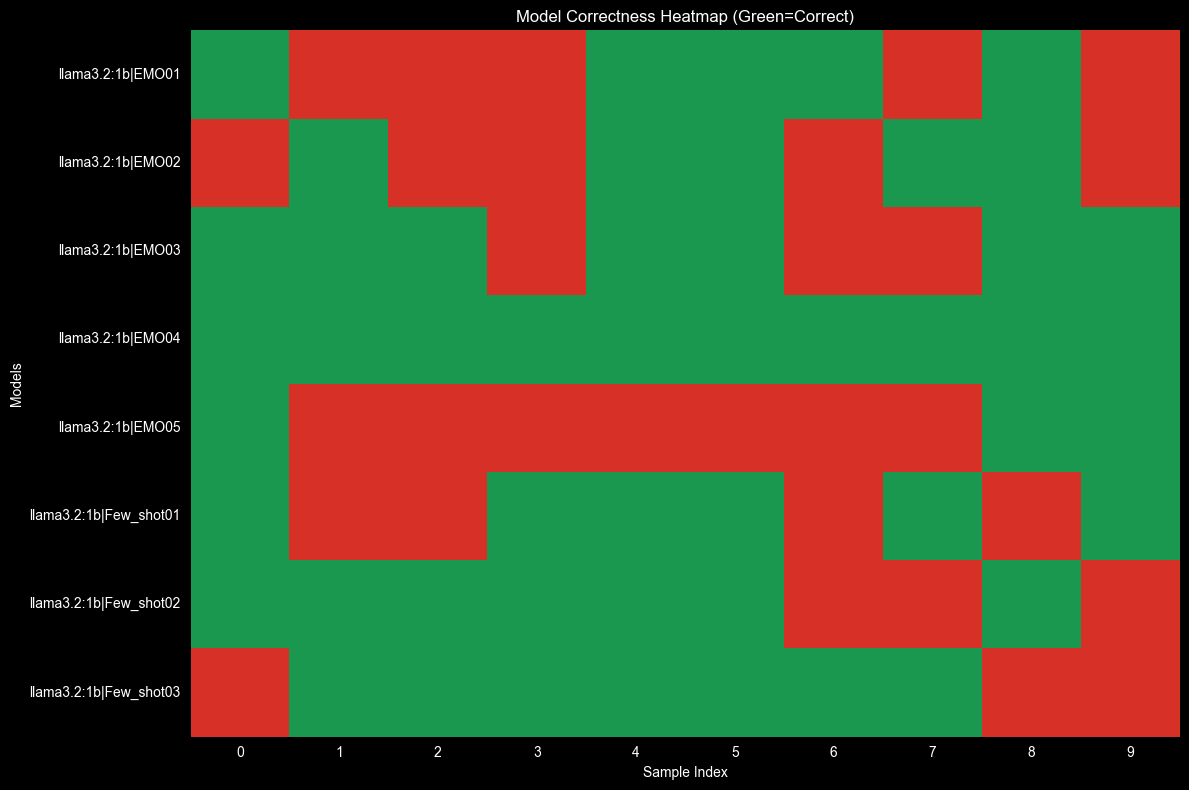

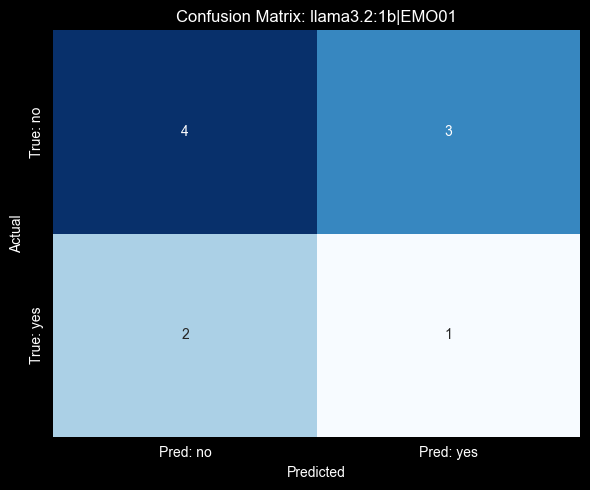

In [18]:
# 對錯熱圖（綠=對、紅=錯）
hm = evalDir / "correctnessHeatmap.png"
if hm.exists():
    display(Image(str(hm)))
# 任一張混淆矩陣
plotsDir = evalDir / "plots"
plots = sorted(plotsDir.glob("*.png")) if plotsDir.exists() else []
if plots:
    display(Image(str(plots[0])))

## 各階段資料格式總表

| 變數 | 型別 | 格式 / 欄位 |
|------|------|-------------|
| `promptTechPoolDict` | `dict` | `{method: {itemKey: text}}` |
| `promptCmbDf` | `DataFrame` | `promptCmbID, promptText` |
| `datasetDf` | `DataFrame` | `taskID, passage, label`（PPI） |
| `labelSet` | `LabelSet` | `classes`（索引=labelCode），`labelToLabelCode()` |
| `finishedTaskRunIDSet` | `set[TaskRunID]` | `(model, promptCmbID, taskID)` |
| `userPromptDf` | `DataFrame` | `taskID, itemList(list), userPrompt, contextDict(dict)` |
| `promptInfoDf` | `DataFrame` | `taskID, model, promptCmbID, sysPrompt, userPrompt, items(list), context(dict)` |
| `raw.csv` | CSV | `RAW_CSV_COLS`；`items/context` 為 JSON 字串、`responseAns` 為 LLM 原文 |
| `resultDf` | `DataFrame` (long) | `sentID, model, promptCmbID, runKey, originalAns, trueLabel, predLabel, responseAns, +context` |
| `partialDf / fullDf` | `DataFrame` (wide) | 每樣本一列；欄 `runKey__pred / __raw / __sysPrompt` |
| `evalSummary.csv` | CSV | 每 runKey 的 Acc/P/R/F1/MCC |

**關鍵轉換點**
- `runKey = model|promptCmbID` 由 `parseToResultDf`（Step 5）一併生成，作為 resultDf 的一級欄位；下游 pivot / saveData 只讀不建（單一來源）。
- 記憶體 `list/dict`（items/context）↔ 落地 CSV 的 **JSON 字串**（`savePromptInfo` / 合成 raw.csv）。
- `long → wide`：`runKey` 從「列的值」變成「欄名」（帶 `__pred/__raw/__sysPrompt` 後綴）。
- 重構後 `promptCmbDf` 全程是 **DataFrame**，`TaskBuilder` 以 `itertuples` 消費、`LLMResultProcessor` 以欄位 `zip` 消費。